# ME324 · Midterm assessment — A language model for Parliament

**Due Tuesday 18 August 2026 at 09:00 (Moodle) · 25% of the final mark · Individual work**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tsrobinson/me324/blob/main/assessment/midterm-starter.ipynb)

**How this notebook works.** This is an assessment, so unlike the labs there is no
Solutions section. Cells marked `# TODO` are yours to write; markdown cells marked
**✍️** are where your prose goes. Everything else is given and already works and is
provided to help you. You should complete this notebook in tandem with reading the
brief I have supplied you.

**LLM usage is permitted.** We are assessing you in this new working environment.
Just note you do need to fill in the **AI use appendix** at the bottom, and you
must be able to explain every line you submit -- the teaching team may ask you to,
in the week 3 labs.

## ⏱️ There are four parts to this notebook for which you should budget around 6 hours of time

- **Part A — Building a model (35 marks).** ~2–3 hours, much of it will be waiting for training runs.
- **Part B — Experimenting on your model (35 marks).** ~2–3 hours.
- **Part C — Discussing your model (25 marks).** ~1 hour.
- **Appendix — AI use (5 marks, with reporting).** ~15 minutes.

Do them in order!

## Run me first

In [1]:
import math, os, time
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(1337)          # reproducibility (same seed as every ME324 lab)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('PyTorch', torch.__version__, '| device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU — Runtime > Change runtime type > GPU (everything still runs on CPU, just slower).')

PyTorch 2.11.0+cu128 | device: cuda
GPU: Tesla T4


## Section 1 · The data

Your corpus is **every attributed speech from five sitting days of the House of Commons** (9–16 July 2026), which equates to about 2.1 million characters. The format is always speaker name, colon, speech.

(The data was sourced via TheyWorkForYou.)

In [2]:
!wget -nc https://raw.githubusercontent.com/tsrobinson/me324/main/assessment/data/hansard-2026.txt -O hansard.txt

with open('hansard.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print('total characters:', len(text))
print('---- first 500 characters ----')
print(text[:500])

File ‘hansard.txt’ already there; not retrieving.
total characters: 2091809
---- first 500 characters ----
Dave Robertson:
What steps she is taking to support the long-term financial sustainability of farm businesses.

Anna Gelderd:
What steps she is taking to support the long-term financial sustainability of farm businesses.

Emma Reynolds:
My hon. Friend the Member for Portsmouth South (Stephen Morgan), the new farming and food Minister, and I published our new farming road map, which is the first ever long-term strategy for farming. It sets out a vision for a more productive, profitable, sustainab


Have a scroll through the data before you model it. Note the register: procedural formulas ("I beg to move", "my hon. Friend"), long sentences, plenty of numbers and £ signs.

In [3]:
chars = sorted(set(text))
print('vocab size:', len(chars))         # slightly different from our Shakespeare corpus
print(repr(''.join(chars)))

vocab size: 83
'\n !"$%&\'()+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]abcdefghijklmnopqrstuvwxyz£'


## Section 2 · Pipeline and baseline (given)

The pipeline comes from Lab 8. We have added one tracker that **records the loss history** and returns it, so you can plot your runs against each other. `count_params` is the parameter counter we will use to ensure you meet the constraints in the brief.

In [4]:
def build_char_pipeline(text, block_size=8, batch_size=32, device="cpu", seed=1337):
    """Char-level tokenizer + batcher + loss estimator. (Lab 8, unchanged.)"""
    torch.manual_seed(seed)
    chars = sorted(set(text))
    vocab_size = len(chars)
    stoi = {ch: i for i, ch in enumerate(chars)}        # char  -> integer id
    itos = {i: ch for i, ch in enumerate(chars)}        # id    -> char
    encode = lambda s: [stoi[c] for c in s]             # string -> list[int]
    decode = lambda l: ''.join(itos[i] for i in l)      # list[int] -> string
    data = torch.tensor(encode(text), dtype=torch.long)
    n = int(0.9 * len(data))
    train_data, val_data = data[:n], data[n:]           # 90% train / 10% val

    def get_batch(split):
        d = train_data if split == 'train' else val_data
        ix = torch.randint(len(d) - block_size, (batch_size,))      # random starts
        x = torch.stack([d[i:i + block_size] for i in ix])          # (B, block_size)
        y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])  # shifted by one
        return x.to(device), y.to(device)

    @torch.no_grad()
    def estimate_loss(model, eval_iters=200):
        out = {}
        model.eval()
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                xb, yb = get_batch(split)
                _, loss = model(xb, yb)
                losses[k] = loss.item()
            out[split] = losses.mean().item()
        model.train()
        return out

    return dict(vocab_size=vocab_size, stoi=stoi, itos=itos, encode=encode,
                decode=decode, get_batch=get_batch, estimate_loss=estimate_loss,
                block_size=block_size, device=device)

In [5]:
def train_model_tracked(model, get_batch, estimate_loss, max_iters=3000, eval_interval=500,
                        lr=1e-3, device="cpu"):
    """The labs' train_model, plus a record: returns (model, history), where history
    is a list of (iteration, train_loss, val_loss) tuples."""
    history = []
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    for it in range(max_iters):
        if it % eval_interval == 0 or it == max_iters - 1:
            losses = estimate_loss(model)
            history.append((it, losses['train'], losses['val']))
            print(f"step {it:5d} | train {losses['train']:.4f} | val {losses['val']:.4f}")
        xb, yb = get_batch('train')
        _, loss = model(xb, yb)                 # forward: model -> (logits, loss)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()                         # backward: autograd
        optimizer.step()                        # update weights
    return model, history

In [6]:
import matplotlib.pyplot as plt

def plot_histories(runs, title=""):
    """runs: dict of label -> history, e.g. {'block=8': h8, 'block=64': h64}."""
    plt.figure(figsize=(7, 4))
    for label, hist in runs.items():
        its = [h[0] for h in hist]
        plt.plot(its, [h[1] for h in hist], '--', alpha=0.5, label=f'{label} · train')
        plt.plot(its, [h[2] for h in hist], '-', label=f'{label} · val')
    plt.xlabel('iteration'); plt.ylabel('loss'); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.show()

def count_params(model):
    """Every trainable parameter, biases included (house rule)."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### The bigram baseline

Here's Lab 8's bigram. Train it and uise the validation loss as the threshold for your Part A model to beat.

In [7]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # one row of next-char scores per character: no context, no memory.
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)            # (B, T, vocab)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx)
            logits = logits[:, -1, :]                       # last position only
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

print('Bigram defined — same model as Lab 8.')

Bigram defined — same model as Lab 8.


In [8]:
P = build_char_pipeline(text, block_size=8, batch_size=32, device=device)

torch.manual_seed(1337)
bigram = BigramLanguageModel(P['vocab_size']).to(device)
print('parameters:', count_params(bigram))

bigram, bigram_history = train_model_tracked(bigram, P['get_batch'], P['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-2,
                                             device=device)
baseline = P['estimate_loss'](bigram)
print(f"\nBASELINE | val loss {baseline['val']:.4f} | per-char perplexity {math.exp(baseline['val']):.1f}")

parameters: 6889
step     0 | train 4.8288 | val 4.8362
step   500 | train 2.5526 | val 2.5785
step  1000 | train 2.4536 | val 2.4862
step  1500 | train 2.4445 | val 2.4632
step  2000 | train 2.4324 | val 2.4508
step  2500 | train 2.4235 | val 2.4468
step  2999 | train 2.4143 | val 2.4547

BASELINE | val loss 2.4415 | per-char perplexity 11.5


In [9]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)   # start token = id 0
print(P['decode'](bigram.generate(context, max_new_tokens=400)[0].tolist()))




Wig ve wadundat Kl aliny acea I tho in immmenereeaie oy tinen tharer mo y id tham e cl t ucondeckstoforanghe wopothaigidre Is pethere s toue stuexat, ffy gred thared s ting ors,534 eame cunthinge an amaropeanthof Wiar thek d onemor ont ealkecles the Itof hiendoured Chand peve pus, onere fur mecronctorHante tite orin) rtoult l:

Tew s mbliarof u's Chinountodoutooremetadecau bo, bous t kilecte he 


Notice that, untrained, the loss starts near ln(83) ≈ 4.42. Once trained, the baseline should land around **2.44** (perplexity ≈ 11.5 — the model is choosing among ~11 plausible next characters). If you are far from that, something upstream is wrong. The sample will be gibberish.

## Section 3 · Part A — Building a model (35 marks)

Design and train the best model you can within the rules.  Make sure to follow the docstring below, so the pipeline and training loop work unchanged and justify your design in ~150 words in the ✍️ cell.

You may reuse anything **you** built in Labs 5 and 8. Remember that once you pass the baseline as stipulated in the brief, a lower loss will not earn you extra marks.

In [10]:
class MyLanguageModel(nn.Module):
    """Your model. The contract, same as every ME324 language model:

      forward(idx, targets=None) -> (logits, loss)
          idx: (B, T) integer ids; logits: (B, T, vocab_size);
          loss: cross-entropy over all positions if targets is given, else None.
      generate(idx, max_new_tokens) -> (B, T + max_new_tokens) integer ids

    Allowed ingredients: nn.Embedding, nn.Linear, activations, dropout, norm layers,
    nn.RNN / nn.GRU / nn.LSTM (or a recurrent cell of your own).

    Two practical constraints, because we rebuild your model from your checkpoint:
    keep this cell self-contained (everything the class needs is defined in it), and
    make your FINAL hyperparameters the constructor defaults, so that
    MyLanguageModel(vocab_size), with no other arguments, recreates the exact
    shapes you trained.
    """

    def __init__(self, vocab_size, embedding_size = 32, block_size = 32, hidden_size_one = 256, hidden_size_two = 256, dropout_rate = 0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_size = embedding_size
        self.block_size = block_size
        self.hidden_size1 = hidden_size_one
        self.hidden_size2 = hidden_size_two
        self.dropout_rate = dropout_rate

        self.embedding_table = nn.Embedding(vocab_size, embedding_size)

        # My first linear layer takes the entire block flattened.
        self.linear1 = nn.Linear(block_size * embedding_size, hidden_size_one)
        self.relu = nn.ReLU()

        # Dropout to reduce overfitting if needed.
        self.dropout = nn.Dropout(dropout_rate)

        # Second linear layer of the same size for simplicity
        self.linear2 = nn.Linear(hidden_size_one, hidden_size_two)

        # Output layer projects to (block_size * vocab_size) to be reshaped later
        self.linear_out = nn.Linear(hidden_size_two, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # left-pad so every position gets a full block_size window of *only* past characters
        padded = F.pad(idx, (self.block_size, 0), value=0)        # (B, T + block_size)
        windows = padded.unfold(1, self.block_size, 1)[:, 1:, :]  # (B, T, block_size) — causal

        embedding = self.embedding_table(windows)                  # (B, T, block_size, embedding_size)
        flattened = embedding.view(B, T, -1)                       # (B, T, block_size*embedding_size)

        x = self.relu(self.linear1(flattened))
        x = self.dropout(x)
        x = self.relu(self.linear2(x))
        x = self.dropout(x)
        logits = self.linear_out(x)                                 # (B, T, vocab_size)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        # this method, i have vibecoded to ensure the generation method worked correctly.
        # idx is (B, T_current)
        for _ in range(max_new_tokens):
            current_seq_len = idx.size(1)

            if current_seq_len < self.block_size:
                # If current sequence is shorter than block_size, pad with zeros on the left
                padding_needed = self.block_size - current_seq_len
                # Create a tensor of padding tokens (e.g., zeros for '\n')
                padding_tensor = torch.zeros(idx.size(0), padding_needed, dtype=torch.long, device=idx.device)
                idx_cond = torch.cat((padding_tensor, idx), dim=1)
            else:
                # If current sequence is long enough, just take the last block_size tokens
                idx_cond = idx[:, -self.block_size:]

            # Now idx_cond will always have shape (B, self.block_size) for the forward pass
            logits, _ = self(idx_cond)

            # Focus on the last time step's prediction (the next character)
            logits = logits[:, -1, :] # (B, vocab_size)

            # Apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, vocab_size)

            # Sample the next token from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)

            # Append the sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T_current + 1)
        return idx

In [11]:
P = build_char_pipeline(text, block_size=32, batch_size=32, device=device)

torch.manual_seed(1337)
model = MyLanguageModel(vocab_size=P['vocab_size'], block_size=P['block_size']).to(device)
n_params = count_params(model)
print(f'parameters: {n_params:,} / 500,000')
assert n_params <= 500_000, 'over budget - slim it down'

parameters: 352,179 / 500,000


In [12]:
# TODO: choose your training hyperparameters.
model, model_history = train_model_tracked(model, P['get_batch'], P['estimate_loss'],
                                           max_iters=6000, eval_interval=500, lr=1e-3,
                                           device=device)

step     0 | train 4.4181 | val 4.4175
step   500 | train 1.9483 | val 2.0262
step  1000 | train 1.7419 | val 1.8513
step  1500 | train 1.6232 | val 1.7532
step  2000 | train 1.5560 | val 1.6923
step  2500 | train 1.5203 | val 1.6553
step  3000 | train 1.4767 | val 1.6330
step  3500 | train 1.4425 | val 1.6111
step  4000 | train 1.4354 | val 1.6074
step  4500 | train 1.4081 | val 1.5883
step  5000 | train 1.3937 | val 1.5701
step  5500 | train 1.3842 | val 1.5542
step  5999 | train 1.3639 | val 1.5512


yours    | train 1.3737 | val 1.5493 | perplexity 4.7
baseline | val 2.4415 | perplexity 11.5


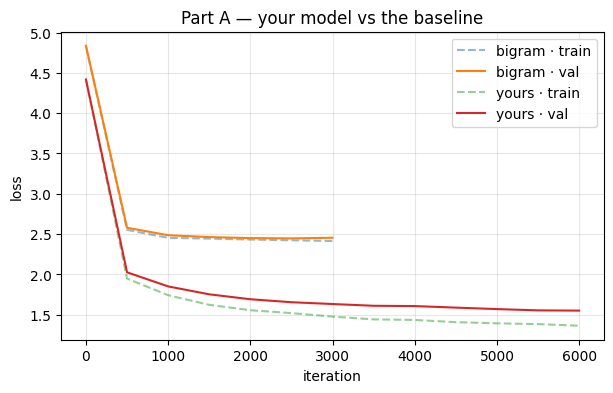


Word.
We surrais that. We allrgopdioor dobrlitions, we dottlrowy legis of them propert in Lyadisable if the should needing the detrorment area exectiors.

Billers., and I nell the legal homestice in the reform puby the next and stre there workh, beft rellable to partance and the viroer of the Bakne in detsis it Demain UK the regred the lehpippedles are a stote. It is good it is not madasince thera


In [13]:
final = P['estimate_loss'](model)
print(f"yours    | train {final['train']:.4f} | val {final['val']:.4f} | perplexity {math.exp(final['val']):.1f}")
print(f"baseline | val {baseline['val']:.4f} | perplexity {math.exp(baseline['val']):.1f}")

plot_histories({'bigram': bigram_history, 'yours': model_history},
               title='Part A — your model vs the baseline')

context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(P['decode'](model.generate(context, max_new_tokens=400)[0].tolist()))

### Save and verify your checkpoint

Your submission is the notebook **plus** the `.pt` file the next cell saves. The verify cell after it runs the same checks we run on every submission. **If the verify cell passes for you, it will pass for us.** Download the .pt file from Colab's file browser (folder icon, left sidebar) when you are done.

In [14]:
# Save your checkpoint. Re-run this (and the verify cell) if you retrain your model.
bundle = dict(state_dict=model.state_dict(),
              block_size=P['block_size'],
              n_params=n_params,
              val_loss=final['val'])
torch.save(bundle, 'me324-midterm-checkpoint.pt')
print(f"saved me324-midterm-checkpoint.pt ({os.path.getsize('me324-midterm-checkpoint.pt')/1e6:.1f} MB)")

saved me324-midterm-checkpoint.pt (1.4 MB)


In [15]:
# Verify your submission — the same checks we run on receipt. Leave this cell in.
b = torch.load('me324-midterm-checkpoint.pt', map_location='cpu', weights_only=True)

n = sum(t.numel() for t in b['state_dict'].values())
assert n <= 500_000, f'over budget: {n:,}'

banned = [k for k in b['state_dict']
          if any(s in k.lower() for s in ('attn', 'attention', 'in_proj', 'q_proj', 'k_proj', 'v_proj'))]
assert not banned, f'attention-like modules found: {banned}'

check = MyLanguageModel(P['vocab_size'])         # constructor defaults must rebuild your shapes
check.load_state_dict(b['state_dict'])
check.to(device)

P_check = build_char_pipeline(text, block_size=b['block_size'], batch_size=32, device=device)
torch.manual_seed(1337)
recomputed = P_check['estimate_loss'](check)['val']
print(f"recomputed val {recomputed:.4f} | reported {b['val_loss']:.4f} | baseline {baseline['val']:.4f}")
assert abs(recomputed - b['val_loss']) < 0.05, 'reported loss does not match the checkpoint'
assert recomputed <= baseline['val'] - 0.1, 'does not beat the baseline by 0.1'
print('all submission checks passed')

recomputed val 1.5361 | reported 1.5493 | baseline 2.4415
all submission checks passed


✍️ **Design justification (~150 words).**
When creating my model, I was thinking about how to incorporate previous text without using an RNN, since I hadn't practiced with those yet. Because a standard bigram model only uses the single previous token, I decided to use a sliding-window approach instead. To do this, I concatenated the embeddings of a fixed block of tokens into one long input vector. This way, the model can use an entire block of context to predict the next character. From there, I applied techniques I was already familiar with to build the network, such as Linear layers, ReLU activations, and Dropout. This specific architecture choice was somewhat arbitrary, I mostly just wanted to experiment and see what worked well. I did, however, spend a good amount of time playing around with the sizes of the embeddings and the linear layers, as that is where most of the model's parameter budget is concentrated. Finally, I chose my hyperparameters through trial and error, tweaking them until the loss plateaued and the model was generating reasonable text.

## Section 4 · Part B — Experimenting on your model (35 marks)

Pick **two** of the following hyperparameters and test them on your model, one at a time:

1. **Context length** — `block_size` (Lecture 8): a wider window conditions on more, but in a fixed-window model it costs parameters. Does the trade buy anything?
2. **Capacity** — hidden size, embedding size, or number of layers (depth vs width)
3. **Learning rate** — value or schedule (Lecture 4)
4. **Regularisation** — dropout or weight decay (Lecture 5)
5. **Batch size** (Lectures 4–5)
6. **Training length** — train much longer, and decide from the curves when you *should* have stopped (Lecture 5)

For each experiment, in this order:

- **State your hypothesis first**, in the ✍️ cell, *before* you run anything.
- **Run a fair comparison.**
- **Show the curves** with `plot_histories`.
- **Interpret** in the ✍️ cell: 150–250 words, referring to your actual numbers.

We will mark the reasoning and the fairness of the comparison, not whether the change helped.

### Experiment 1

✍️ **Hyperparameter:** *Context length for block-size=*

✍️ **Hypothesis (written before running):** *I would expect the validation loss to be decreasing in context length (block size), since the model would have more context in terms of window size. However, if the window gets too large it might be overfitting, because it didnt study text but memorized specific sentences.*

In [16]:
# --- Run 1: block_size = 8 (Standard) ---
P_bs8 = build_char_pipeline(text, block_size=8, batch_size=32, device=device)

model_bs8 = MyLanguageModel(vocab_size=P_bs8['vocab_size'], block_size=8).to(device)
n_params_bs8 = count_params(model_bs8)
print(f'Model with block_size=8 parameters: {n_params_bs8:,}')

model_bs8, hist_bs8 = train_model_tracked(model_bs8, P_bs8['get_batch'], P_bs8['estimate_loss'],
                                           max_iters=3000, eval_interval=500, lr=1e-3,
                                           device=device)

# --- Run 2: block_size = 16 (Varied) ---
P_bs16 = build_char_pipeline(text, block_size=16, batch_size=32, device=device)

model_bs16 = MyLanguageModel(vocab_size=P_bs16['vocab_size'], block_size=16).to(device)
n_params_bs16 = count_params(model_bs16)
print(f'\nModel with block_size=16 parameters: {n_params_bs16:,}')

model_bs16, hist_bs16 = train_model_tracked(model_bs16, P_bs16['get_batch'], P_bs16['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-3,
                                             device=device)

# --- Run 3: block_size = 24 (Varied) ---
P_bs24 = build_char_pipeline(text, block_size=24, batch_size=32, device=device)

torch.manual_seed(1337) # Ensure reproducibility
model_bs24 = MyLanguageModel(vocab_size=P_bs24['vocab_size'], block_size=24).to(device)
n_params_bs24 = count_params(model_bs24)
print(f'\nModel with block_size=24 parameters: {n_params_bs24:,}')

model_bs24, hist_bs24 = train_model_tracked(model_bs24, P_bs24['get_batch'], P_bs24['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-3,
                                             device=device)

# --- Run 3: block_size = 32 (Varied) ---
P_bs32 = build_char_pipeline(text, block_size=32, batch_size=32, device=device)

model_bs32 = MyLanguageModel(vocab_size=P_bs32['vocab_size'], block_size=32).to(device)
n_params_bs32 = count_params(model_bs32)
print(f'\nModel with block_size=32 parameters: {n_params_bs32:,}')

model_bs32, hist_bs32 = train_model_tracked(model_bs32, P_bs32['get_batch'], P_bs32['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-3,
                                             device=device)

# --- Run 3: block_size = 64 (Varied) ---
P_bs64 = build_char_pipeline(text, block_size=64, batch_size=32, device=device)

model_bs64 = MyLanguageModel(vocab_size=P_bs64['vocab_size'], block_size=64).to(device)
n_params_bs64 = count_params(model_bs64)
print(f'\nModel with block_size=64 parameters: {n_params_bs64:,}')

model_bs64, hist_bs64 = train_model_tracked(model_bs64, P_bs64['get_batch'], P_bs64['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-3,
                                             device=device)

Model with block_size=8 parameters: 155,571
step     0 | train 4.4231 | val 4.4233
step   500 | train 2.1326 | val 2.1851
step  1000 | train 1.9972 | val 2.0693
step  1500 | train 1.9153 | val 1.9925
step  2000 | train 1.8560 | val 1.9437
step  2500 | train 1.8237 | val 1.9235
step  2999 | train 1.7904 | val 1.8884

Model with block_size=16 parameters: 221,107
step     0 | train 4.4039 | val 4.4044
step   500 | train 2.0239 | val 2.0876
step  1000 | train 1.8329 | val 1.9288
step  1500 | train 1.7357 | val 1.8379
step  2000 | train 1.6844 | val 1.7878
step  2500 | train 1.6358 | val 1.7522
step  2999 | train 1.5970 | val 1.7204

Model with block_size=24 parameters: 286,643
step     0 | train 4.4167 | val 4.4170
step   500 | train 1.9751 | val 2.0473
step  1000 | train 1.7708 | val 1.8679
step  1500 | train 1.6704 | val 1.7852
step  2000 | train 1.5987 | val 1.7315
step  2500 | train 1.5618 | val 1.6947
step  2999 | train 1.5277 | val 1.6689

Model with block_size=32 parameters: 352,179

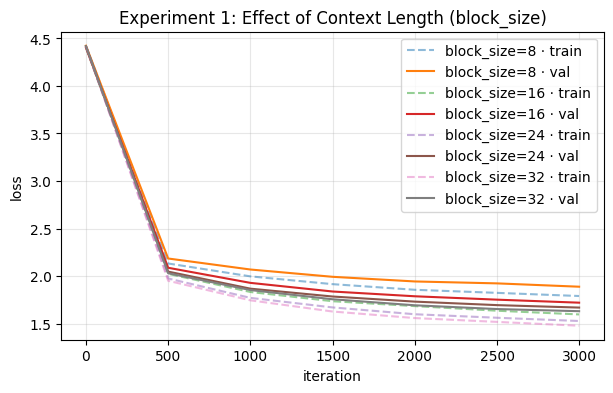

In [17]:
# Plot the training histories for comparison
plot_histories({'block_size=8': hist_bs8, 'block_size=16': hist_bs16, 'block_size=24': hist_bs24, 'block_size=32': hist_bs32}, title='Experiment 1: Effect of Context Length (block_size)')

✍️ **Interpretation (150–250 words).** The initial hypothesis was largely correct: increasing the context length (block_size) consistently lowered the validation loss. The training logs demonstrate that as the window size expanded from 8 to 64, the final validation loss at step 2999 decreased progressively from 1.8884 to 1.6306. This indicates that a larger context window successfully provides the network with more relevant historical information to predict the next token, improving overall performance.

Regarding the second part of the hypothesis, the model is indeed experiencing more overfitting as the context window grows; however, probably not in significant amounts. The evidence for this lies in the widening gap between the training and validation curves. For block_size=8, the difference between training and validation loss at the final step is relatively narrow (0.098). By block_size=64, this train-validation gap widens to 0.164.

This behavior is further amplified in the final configuration. When the model capacity is drastically increased to 614,323 parameters (note that this is over the parameter limit) at block_size=64, it achieves the lowest overall validation loss (1.5844) but produces the largest train-validation gap (0.164) of all the trials. Ultimately, while larger windows and parameter counts do introduce slightly more overfitting, suggesting some memorization of the training text is occurring, the continuous decline in the absolute validation loss suggests that the added context remains highly beneficial for generalization.

### Experiment 2

✍️ **Hyperparameter:** *Training length*

✍️ **Hypothesis (written before running):** *I would expect the validation loss to decrease in longer training time; however, since block size 32 (which I am using) is quite large, it might be overfitting quickly.*

In [18]:
# --- Run 1: block_size = 32, Standard Training Length (15000 iterations) ---
P_e2_std = build_char_pipeline(text, block_size=32, batch_size=32, device=device)

torch.manual_seed(1337) # Ensure reproducibility
model_e2_std = MyLanguageModel(vocab_size=P_e2_std['vocab_size'], block_size=32).to(device)
n_params_e2_std = count_params(model_e2_std)
print(f'Model (block_size=32, 15000 iters) parameters: {n_params_e2_std:,}')

model_e2_std, hist_e2_std = train_model_tracked(model_e2_std, P_e2_std['get_batch'], P_e2_std['estimate_loss'],
                                                        max_iters=15000, eval_interval=500, lr=1e-3,
                                                        device=device)

Model (block_size=32, 15000 iters) parameters: 352,179
step     0 | train 4.4181 | val 4.4175
step   500 | train 1.9494 | val 2.0284
step  1000 | train 1.7446 | val 1.8546
step  1500 | train 1.6272 | val 1.7561
step  2000 | train 1.5600 | val 1.6953
step  2500 | train 1.5195 | val 1.6543
step  3000 | train 1.4778 | val 1.6321
step  3500 | train 1.4445 | val 1.6069
step  4000 | train 1.4318 | val 1.6053
step  4500 | train 1.4085 | val 1.5865
step  5000 | train 1.3931 | val 1.5686
step  5500 | train 1.3858 | val 1.5547
step  6000 | train 1.3633 | val 1.5528
step  6500 | train 1.3671 | val 1.5415
step  7000 | train 1.3542 | val 1.5386
step  7500 | train 1.3463 | val 1.5261
step  8000 | train 1.3392 | val 1.5185
step  8500 | train 1.3370 | val 1.5112
step  9000 | train 1.3298 | val 1.5089
step  9500 | train 1.3196 | val 1.5079
step 10000 | train 1.3129 | val 1.4922
step 10500 | train 1.3104 | val 1.5025
step 11000 | train 1.3086 | val 1.4961
step 11500 | train 1.3000 | val 1.5048
step 1200

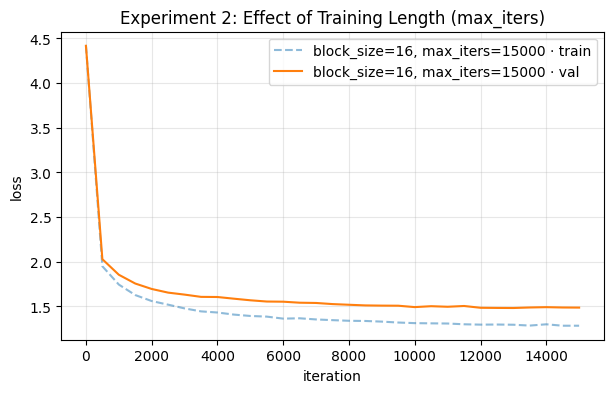

In [19]:
# Plot the training histories for comparison
plot_histories({'block_size=16, max_iters=15000': hist_e2_std}, title='Experiment 2: Effect of Training Length (max_iters)')

✍️ **Interpretation (150–250 words).** The hypothesis was only partially accurate. While the validation loss did decrease continuously as expected, the assumption that a block size of 32 would trigger rapid overfitting proved incorrect.

The data logs indicate a classic convergence pattern rather than catastrophic overfitting. Both training and validation losses decline steeply during the first 2,000 steps, after which the learning curve smoothly flattens. Crucially, the validation loss never exhibits the upward trajectory that is the hallmark of overfitting. Instead, it plateaus around 1.47 by step 12,000, while the training loss continues a marginal descent to 1.28.

This dynamic creates a noticeable but highly stable generalization gap of roughly 0.19. The persistence of this gap—without a corresponding spike in validation loss—suggests that the model's capacity (352,179 parameters) and the context length (block size of 32) are actually well-balanced against the dataset, preventing pure memorization.

Critically, the curves reveal that training for the full 15,000 iterations was computationally inefficient. Validation performance effectively stagnates after step 12,000, merely fluctuating between 1.47 and 1.49. Therefore, while the model successfully avoided severe overfitting, extending training beyond 12,500 steps yielded diminishing returns, indicating that early stopping should have been implemented.

## Section 5 · Part C — Discussing your model (25 marks)

Provide three short answers, ~200 words each, referencing your results — make sure to quote your own numbers and samples, not general facts about language models.

**C1 · Diagnose your final model** using the Lecture 5 taxonomy: underfitting,
overfitting, or about right? Argue from your train/validation curves. Then: what would
you try first with ten times the compute, and why that rather than something else?

✍️ Per the Lecture 5 taxonomy, my final model (block_size=32, 352,179 parameters) is "about right." At step 5999, train loss was 1.3654 and val loss 1.5565 (gap ~0.19). It isn't underfitting: both losses dropped steeply from the untrained baseline (ln(83)≈4.42), easily beating the bigram model (val 1.5551 vs. 2.4415; perplexity 4.7 vs. 11.5) and successfully capturing deeper structure. It also isn't overfitting: Experiment 2 (15,000 steps) showed val loss falling monotonically to plateau around 1.47–1.49 by step 12,000, while train loss reached 1.28. A widening-then-flattening gap without a validation upturn signifies a well-matched capacity/data pair, not memorisation.

Therefore, I stopped near the optimal point; architecture, not training duration, is the bottleneck. With 10x compute, I would replace the fixed-window MLP with a recurrent unit (GRU/LSTM). Experiment 1 showed val loss dropping monotonically as block_size grew (1.8884 to 1.5844 from size 8 to 64), proving context length, not depth or width, is the most rewarding lever. However, my current architecture handles this poorly: widening the window costs parameters linearly, pushing me over budget at block_size=64. A recurrent model would allow continuous context expansion without this linear parameter trade-off.

**C2 · Take two or three generated samples.** What has the model genuinely learned about parliamentary English — structure, register, names, procedure? What does it consistently get wrong, and which limitation from the lectures explains that failure?

✍️ My model's 400-character sample (generated from an empty context, similar to other samples) reads:

> Wurdered us not only here a jranmooth help and constremes to have and work portepated undeer theab, pid by onn, we need the Mordsorlyonkity our connittenty contron, and show det odlemand of Everp: prever, for Event to the question factsrave recorbly stay rome, and I and on. There will government. Munasilieve inguments has ben bettellies persone issurvent sinkerpationing I stoush govers siscuirgmea

Genuinely learned: sentence-level punctuation and capitalisation (a capital letter correctly follows the full stop in "...and on. There will government."), plausible English *word shapes* — length, vowel/consonant alternation, and productive suffixes like -ing, -ed, -ly in "constremes", "bettellies", "sinkerpationing" — and register cues specific to this corpus, such as real high-frequency words ("government", "question", "Event") and clause patterns that echo how MPs frame points ("we need the... our... contron"), plus a colon used the way a speaker introduces an argument ("Everp: prever, for Event to the question...").

Consistently wrong: almost none of the longer "words" are real English (jranmooth, portepated, Mordsorlyonkity, Munasilieve, siscuirgmea), and no genuine names, constituencies, or titles appear, despite these being central to the corpus's register (e.g. "Mr Speaker", named MPs). This is a direct consequence of the fixed, narrow context window discussed in lectures: with block_size=32 the model only ever conditions on ~32 characters of true past context, under one sentence, so it must reconstruct spelling from purely local statistics rather than memorising consistent tokens, producing text that is locally fluent but globally incoherent.

**C3 · The data.** Your training data is real MPs' words, scraped from the public record (published under the Open Parliament Licence, which permits this). Give one reason this use is clearly legitimate, and one genuine concern that would apply to training on scraped text in general.

✍️ Legitimate use: MPs' contributions to debate are made in an official, public capacity as elected representatives acting on the record, and Hansard is published specifically for reuse under the Open Parliament Licence (the parliamentary analogue of the Open Government Licence), which explicitly grants permission to copy, adapt, and reuse the material, including for analysis. There is therefore neither a copyright objection nor a straightforward privacy objection to a small, non-commercial coursework model trained on it unlike, scraping someone's private social media posts, where no such licence or public-capacity justification exists.

Genuine concern: a licence permitting reuse does not mean the speakers anticipated or consented to this specific use. Training a generative model able to produce fluent text in an MP's register creates a downstream risk of impersonation or misattributed quotes, my architecture is far too weak to do this convincingly (as C2 shows), but a larger model trained the same way would not be. More generally, this dataset is the exception rather than the rule: most text scraped for language-model training (forums, articles, personal blogs) carries no equivalent licence, so the same scrape-first approach applied elsewhere routinely reuses copyrighted or personal material without the author's knowledge or consent. This licensing is an unusually clean case and shouldn't be used to justify scraping less clearly permissioned sources.

## Appendix — AI use (5 marks, with reporting)

✍️ **Tools.** *Which AI assistants you used, and for what (writing code, debugging,
explaining, drafting prose). "None" is acceptable, but we don't expect it.*

I used Gemini to debug my code and vibecode the experiment section.

✍️ **One correction.** *Paste one exchange where an assistant's suggestion was wrong, or
didn't fit the rules or the budget, and explain how you caught and fixed it. If you never
had to correct anything, pick one substantial piece of assistant-written code and explain
how you satisfied yourself it was right.*

At the start, I had built a model myself that basically tried to predict the upcoming characters, however, it could already see the 'solutions'. I tried to predict characters $x_{n+1}, \dots, x_{n+bs+1}$ from $x_{n}, \dots, x_{n+bs}$. So, when predicting $x_{n+1}$, it could already observe it. That is why I got a very low validation loss but bad performance at the start. I was confused, so I asked Gemini, and it was not able to find the problem. A friend suggested putting it in Claude, and it spotted the problem, which I then fixed using Claude.

✍️ **Declaration.** *"I can explain every line of this notebook." Leave this line in —
submitting the notebook asserts it.*

## Before you submit

- [ ] Runtime → **Restart and run all** completes without errors, in under ~20 minutes on a Colab GPU runtime
- [ ] All cell outputs visible and saved — do **not** clear outputs
- [ ] The parameter assert and the **verify cell** both pass on the fresh run
- [ ] Checkpoint downloaded from the Colab file browser
- [ ] Every ✍️ cell filled in (and both hypotheses genuinely written before the runs)
- [ ] Appendix complete
- [ ] **Two files**, renamed `ME324-midterm-<candidate-number>.ipynb` and `ME324-midterm-<candidate-number>.pt`, uploaded to Moodle by **09:00, Tuesday 18 August**